In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize

import astropy.units as u
from matplotlib.colors import TwoSlopeNorm

from tqdm import tqdm

from scipy.optimize import curve_fit

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Column 1:  magnetic flux values given in integer multiples of 1e17 Maxwells

Column 2:  x_i  (in units of Mm)

Column 3:  y_i  (in units of Mm)

In [2]:
filename = 'data/full_xi0.50.out'
df = pd.read_csv(filename, sep='  ', skiprows=2, names=['Phi_i', 'x_i', 'y_i'], engine='python')

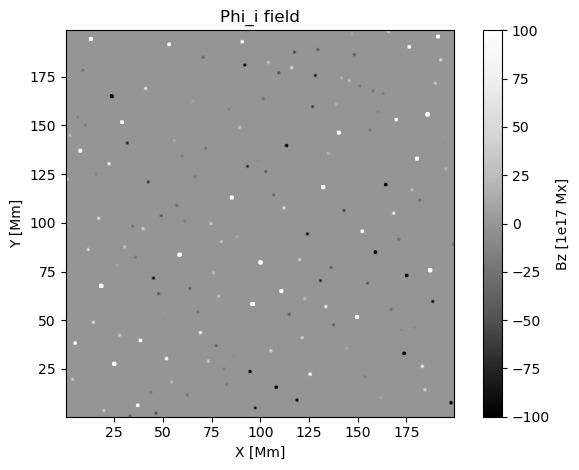

In [3]:
grid = df.pivot(index='y_i', columns='x_i', values='Phi_i').fillna(0)

plt.imshow(grid, origin='lower',  # 'lower' puts y=0 at bottom
           aspect='equal',
           extent=[grid.columns.min(), grid.columns.max(),
                   grid.index.min(),   grid.index.max()], 
           cmap='Greys_r', 
           vmin=-100, 
           vmax=100)

plt.colorbar(label='Bz [1e17 Mx]')
plt.xlabel('X [Mm]')
plt.ylabel('Y [Mm]')
plt.title('Phi_i field')
plt.tight_layout()
plt.show()

In [4]:
def calc_B(df, z):
    # Define your evaluation grid
    x_vals = np.linspace(df.x_i.min(), df.x_i.max(), 200)
    y_vals = np.linspace(df.y_i.min(), df.y_i.max(), 200)
    
    X, Y = np.meshgrid(x_vals, y_vals)  # shape (ny, nx)
    
    # Evaluation points r = (x, y, z)
    rx = X[..., np.newaxis]  # (ny, nx, 1)
    ry = Y[..., np.newaxis]
    rz = np.full_like(rx, z)
    
    # Source positions r_i = (x_i, y_i, 0)
    xi = df.x_i.values  # (n_sources,)
    yi = df.y_i.values
    phi = df.Phi_i.values
    
    # Displacement vectors r - r_i, shape (ny, nx, n_sources)
    dx = rx - xi
    dy = ry - yi
    dz = rz - (-1.0)  # sources assumed at z=-1.0
    
    dist = np.sqrt(dx**2 + dy**2 + dz**2)  # (ny, nx, n_sources)
    
    # Sum over sources: B = sum_i (Phi_i / 2pi) * (r - r_i) / |r - r_i|^3
    weight = phi / (2 * np.pi) / dist**3  # (ny, nx, n_sources)
    
    Bx = np.sum(weight * dx, axis=-1)  # (ny, nx)
    By = np.sum(weight * dy, axis=-1)
    Bz = np.sum(weight * dz, axis=-1)
    Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

    return Bx, By, Bz, Bmag

In [5]:
# z = (6.1 * 10**6 * u.km).to(u.Mm).value # ~ PSP height
# z = (10 * u.R_sun).to(u.Mm).value # ~ PSP height
z = 10
Bx, By, Bz, Bmag = calc_B(df, z=z)

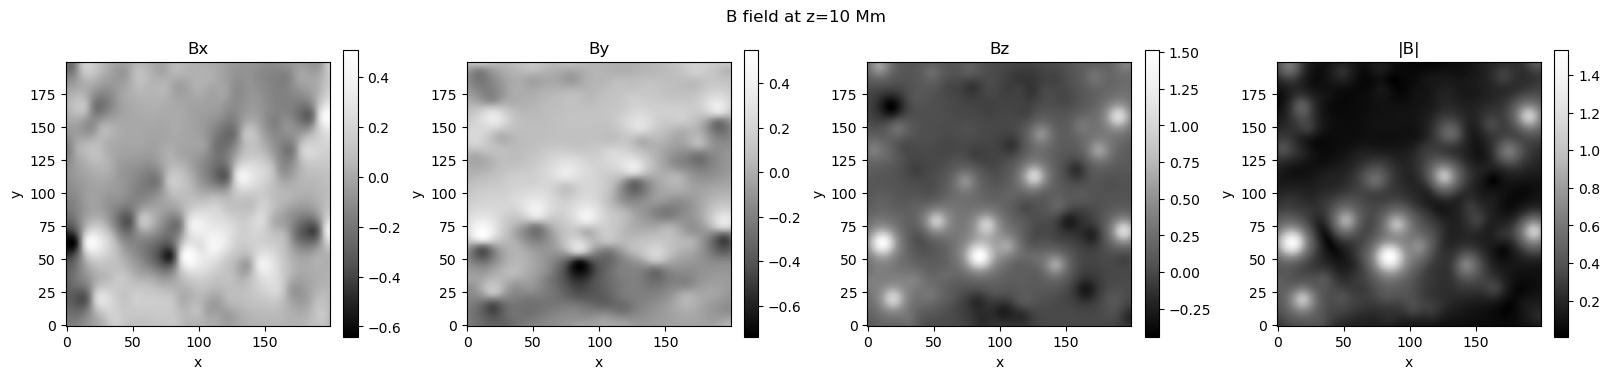

In [6]:
Bx, By, Bz, Bmag = calc_B(df, z=z)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), layout='compressed')

for ax, data, title in zip(axes, [Bx, By, Bz, Bmag], ['Bx', 'By', 'Bz', '|B|']):
    im = ax.imshow(data, origin='lower', aspect='equal', cmap='Greys_r')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle(f'B field at z={z} Mm')
plt.show()

In [7]:
# =============================================================================
# LOAD DATA
# =============================================================================

filename = filename
df = pd.read_csv(filename, sep=r'\s+', skiprows=2,
                 names=['Phi_i', 'x_i', 'y_i'], engine='python')

# df = df_y_extend

xi = df.x_i.values
yi = df.y_i.values
phi = df.Phi_i.values
Z_SOURCES = -1.0   # Mm below photosphere
GAUSS = 10.0 * 1e5  # 1e17 Mx/Mm² → nanoTesla

# =============================================================================
# CORE FUNCTION
# =============================================================================

def calc_B(x, y, z, xi, yi, phi, z_sources=-1.0):
    """
    Compute B vector at arbitrary points (x, y, z).

    x, y, z : floats or arrays of shape (...)
    xi, yi  : source positions, shape (n,)
    phi     : source fluxes,    shape (n,)

    Returns Bx, By, Bz in nT (same shape as x).
    """
    # add trailing source axis so broadcasting works
    x = np.asarray(x)[..., np.newaxis]
    y = np.asarray(y)[..., np.newaxis]
    z = np.asarray(z)[..., np.newaxis]

    dx = x - xi
    dy = y - yi
    dz = z - z_sources

    dist   = np.sqrt(dx**2 + dy**2 + dz**2)
    weight = phi / (2 * np.pi) / dist**3

    Bx = np.sum(weight * dx, axis=-1) * GAUSS
    By = np.sum(weight * dy, axis=-1) * GAUSS
    Bz = np.sum(weight * dz, axis=-1) * GAUSS
    return Bx, By, Bz

# =============================================================================
# GRID + SLICES
# =============================================================================

def make_grid(nx=100, ny=100):
    x = np.linspace(xi.min(), xi.max(), nx)
    y = np.linspace(yi.min(), yi.max(), ny)
    return np.meshgrid(x, y)   # X, Y each (ny, nx)

def compute_slices(z_values, X, Y):
    """Return list of Bz grids, one per z in z_values."""
    slices = []
    for z in z_values:
        _, _, Bz = calc_B(X, Y, z, xi, yi, phi)
        slices.append(Bz)
    return slices

# =============================================================================
# PSP TRAJECTORY
# =============================================================================

def make_psp_trajectory(z_psp, speed=0.2, y_offset=0.0, dt=1.0):
    """
    Straight-line PSP pass at fixed height z_psp.
    speed     : Mm/s  (default 0.2 Mm/s ~ 200 km/s)
    y_offset  : shift from domain midplane in Mm
    Returns t, x_psp, y_psp, z_psp_arr
    """
    x_start, x_end = xi.min(), xi.max()
    t_total = (x_end - x_start) / speed
    t       = np.arange(0, t_total, dt)

    x_psp     = np.linspace(x_start, x_end, len(t))
    y_psp     = np.full_like(t, (yi.min() + yi.max()) / 2 + y_offset)
    z_psp_arr = np.full_like(t, z_psp)
    return t, x_psp, y_psp, z_psp_arr

# =============================================================================
# PLOT
# =============================================================================

def plot_psp(z_psp, n_slices=6, speed=0.2, y_offset=0.0):

    X, Y = make_grid()
    z_values = np.linspace(1.0, z_psp, n_slices)   # start at 1 to avoid near-singularity
    slices   = compute_slices(z_values, X, Y)

    # PSP trajectory + measured Bz
    t, x_psp, y_psp, z_psp_arr = make_psp_trajectory(z_psp, speed, y_offset)
    Bx_psp, By_psp, Bz_psp = calc_B(x_psp, y_psp, z_psp_arr, xi, yi, phi)
    Bmag_psp = np.sqrt(Bx_psp**2 + By_psp**2 + Bz_psp**2)

    # ---- figure ----
    fig = plt.figure(figsize=(14, 6))
    ax3d = fig.add_subplot(121, projection='3d')
    ax_ts = fig.add_subplot(122)

    # stacked slices
    for z, Bz in zip(z_values, slices):
        vmax = np.max(np.abs(Bz))
        norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
        colors = plt.cm.Greys_r(norm(Bz))
        colors[..., 3] = 1.0  # alpha
        ax3d.plot_surface(X, Y, np.full_like(X, z),
                          facecolors=colors,
                          rstride=1, cstride=1,
                          linewidth=0, antialiased=False)
        # # border
        # x_min, x_max = X[0, 0], X[0, -1]
        # y_min, y_max = Y[0, 0], Y[-1, 0]
        # corners_x = [x_min, x_max, x_max, x_min, x_min]
        # corners_y = [y_min, y_min, y_max, y_max, y_min]
        # corners_z = [z] * 5
        # ax3d.plot(corners_x, corners_y, corners_z, color='k', lw=2, alpha=1)

    # PSP trajectory
    ax3d.plot(x_psp, y_psp, z_psp_arr, color='red', lw=2, label='PSP', zorder=100)
    ax3d.plot([x_psp[-1]], [y_psp[-1]], [z_psp_arr[-1]],
              marker=(3, 0, 0),
              color='red', markersize=8, zorder=100)

    ax3d.set_xlabel('x (Mm)')
    ax3d.set_ylabel('y (Mm)')
    ax3d.set_zlabel('z (Mm)')
    ax3d.set_title('Bz slices + PSP trajectory')
    ax3d.legend(loc='upper left', framealpha=0)

    # Bz timeseries
    ax_ts.plot(t, Bx_psp, color='#D81B60', lw=1, label='Bx')
    ax_ts.plot(t, By_psp, color='#1E88E5', lw=1, label='Bz')
    ax_ts.plot(t, Bz_psp, color='#FFC107', lw=1, label='Bz')
    ax_ts.plot(t, Bmag_psp, color='k', lw=1, label='Bmag')
    
    ax_ts.axhline(0, color='gray', lw=1, ls='--')
    ax_ts.set_xlabel('Time (s)')
    ax_ts.set_ylabel('(nT)')
    ax_ts.set_title(f'Bz measured by PSP  (z = {z_psp:.0f} Mm)')
    ax_ts.grid(True, alpha=0.3)
    ax_ts.legend()
    ax_ts.set_xlim(0, max(t))

    plt.tight_layout()
    plt.show()

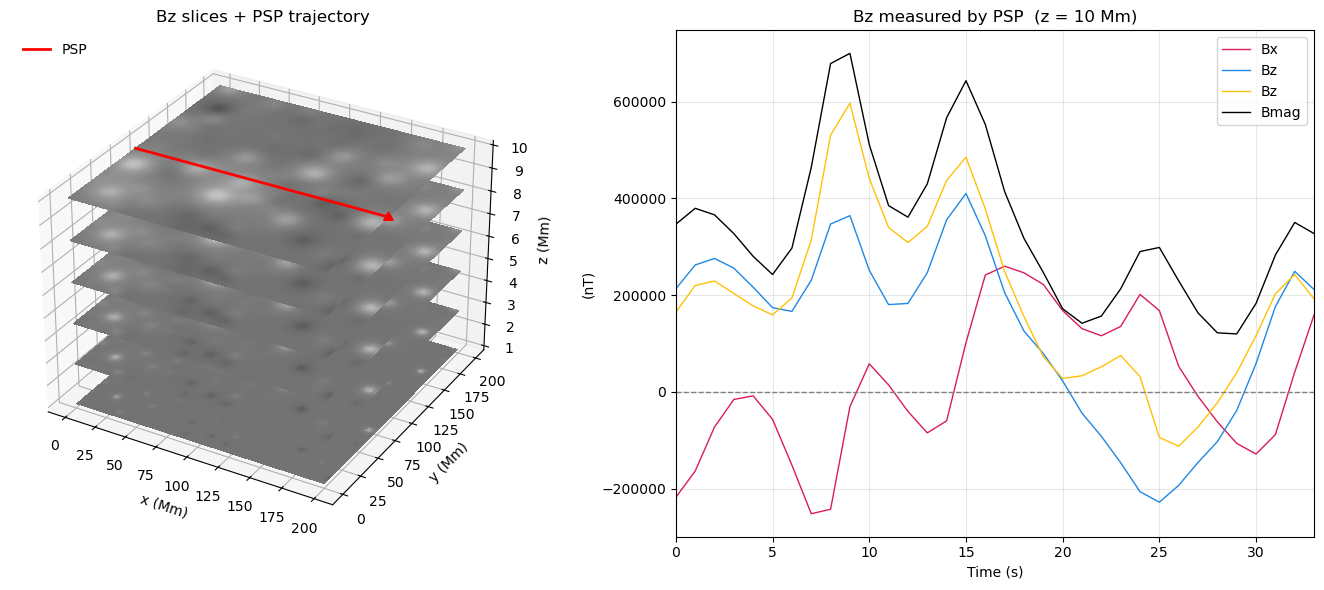

In [8]:
# =============================================================================
# RUN
# =============================================================================

speed = (692000 * u.km/u.s).to(u.Mm/u.s).value
z_psp = (6.1 * 10**6 * u.km).to(u.Mm).value

plot_psp(
    z_psp    = 10,   # Mm
    n_slices = 6,
    speed    = 6,    # Mm/s
    y_offset = -15.0,  # Mm from midplane
)

small length and follow it -- comput field and direction and follow it down
top most Bz mus be pointed downwards and carry that sign through
whats the optimal size

vector tracing

spacecraft constant speed, each point on the surface different speed
does that speed correlate with the field strength when it gets to the bottom

scatterplot of field strength vs percieved speed of footpoint

In [9]:
def adaptive_ds(z, ds_min=0.03, ds_max=10.0, z_max=200.0):
    """
    Adaptive step size that varies with height z.
    ds_min : step size at photosphere (z=0)  in Mm
    ds_max : step size at z=z_max            in Mm
    z_max  : height at which ds = ds_max     in Mm
    """
    zeta = np.clip(z, 0.0, z_max) / z_max
    return ds_min**(1 - zeta) * ds_max**zeta
    

def trace_fieldline(x0, y0, z0, xi, yi, phi,
                    ds_min=0.03, ds_max=10.0, z_max=200.0, z_stop=0.0):
    """
    Trace a field line from (x0, y0, z0) down to z_stop.
    ds       : step size in Mm — smaller = more accurate but slower
    Returns arrays of (x, y, z) along the field line.
    """
    pos = np.array([x0, y0, z0], dtype=float)
    path = [pos.copy()]

    # max_steps = int(30 * (z0 - z_stop) / ds) # x10
    curr_z = z0
    
    sign = None

    # for i in range(max_steps):
    while curr_z > z_stop:
        Bx, By, Bz = calc_B(pos[0], pos[1], pos[2], xi, yi, phi)
        B = np.array([Bx, By, Bz])
        Bmag = np.sqrt(np.sum(B**2))

        # if Bmag == 0:
        #     break

        b_hat = B / Bmag

        # determine sign once at the start and keep it for the whole trace
        if sign is None:
            sign = -1 if b_hat[2] > 0 else +1

        # step size based on current height
        ds = adaptive_ds(pos[2], ds_min, ds_max, z_max)

        pos = pos + ds * sign * b_hat
        path.append(pos.copy())

        curr_z = pos[2]

        # if pos[2] <= z_stop:
        #     break

    return np.array(path)


def trace_all_footpoints(x_psp, y_psp, z_psp_arr, xi, yi, phi,
                          ds=5.0, subsample=10):
    """
    Trace field line from each PSP position down to z=0.
    subsample : only trace every Nth PSP point (saves time)
    Returns footpoints (x_foot, y_foot) and field strength at footpoint.
    """
    idx = np.arange(0, len(x_psp), subsample)

    x_foot  = np.zeros(len(idx))
    y_foot  = np.zeros(len(idx))
    B_foot  = np.zeros(len(idx))   # |B| at footpoint
    B_psp   = np.zeros(len(idx))   # |B| at PSP height

    for n, i in enumerate(idx):
        # |B| at PSP
        Bx, By, Bz = calc_B(x_psp[i], y_psp[i], z_psp_arr[i], xi, yi, phi)
        B_psp[n] = np.sqrt(Bx**2 + By**2 + Bz**2)

        # trace down
        path = trace_fieldline(x_psp[i], y_psp[i], z_psp_arr[i],
                                xi, yi, phi)

        x_foot[n] = path[-1, 0]
        y_foot[n] = path[-1, 1]

        # |B| at footpoint
        Bx, By, Bz = calc_B(path[-1, 0], path[-1, 1], path[-1, 2],
                              xi, yi, phi)
        B_foot[n] = np.sqrt(Bx**2 + By**2 + Bz**2)

    return x_foot, y_foot, B_foot, B_psp, idx


def plot_fieldline_traces(x_psp, y_psp, z_psp_arr, t, xi, yi, phi,
                          ds=5.0, subsample=10):

    idx = np.arange(0, len(x_psp), subsample)

    # compute Bz at photosphere for the floor
    X, Y = make_grid()
    _, _, Bz_floor = calc_B(X, Y, 0.0, xi, yi, phi)  # z=0.1 to avoid singularity
    vmax = np.max(np.abs(Bz_floor))
    norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    floor_colors = plt.cm.Greys_r(norm(Bz_floor))
    floor_colors[..., 3] = 1.0

    fig = plt.figure(figsize=(15, 8), layout='compressed')
    ax = fig.add_subplot(121, projection='3d')
    # ax.view_init(elev=0, azim=0, roll=15)
    # fig.patch.set_facecolor('#0d0d0d')
    # ax.set_facecolor('#0d0d0d')

    ax.computed_zorder = False

    # photosphere floor with Bz colors
    ax.plot_surface(X, Y, np.zeros_like(X),
                    facecolors=floor_colors,
                    rstride=1, cstride=1,
                    linewidth=0, antialiased=False, zorder=0)

    # field lines
    colors = plt.cm.plasma(np.linspace(0, 1, len(idx)))
    for color, i in zip(colors, idx):
        path = trace_fieldline(x_psp[i], y_psp[i], z_psp_arr[i],
                                xi, yi, phi)
        ax.plot(path[:, 0], path[:, 1], path[:, 2],
                color=color, lw=0.8, alpha=0.7)
        ax.scatter(path[0, 0], path[0, 1], path[0, 2],
                   color=color, s=10, zorder=10)
        # ax.scatter(path[-1, 0], path[-1, 1], path[-1, 2],
        #            color=color, s=20, marker='x', zorder=10)

    # PSP trajectory
    # ax.plot(x_psp, y_psp, z_psp_arr,
    #         color='white', lw=2, ls='--', alpha=0.8, label='PSP')

    ax.set_xlabel('x (Mm)')#; ax.xaxis.label.set_color('white')
    ax.set_ylabel('y (Mm)')#; ax.yaxis.label.set_color('white')
    ax.set_zlabel('z (Mm)')#; ax.zaxis.label.set_color('white')
    # ax.set_title('Field line traces: PSP → photosphere')#, color='white')
    # ax.tick_params(colors='white')
    # ax.legend()


    # side plot
    ax = fig.add_subplot(122)
    ax.set_box_aspect(0.8) # adjust plot width/height ratio
    # ax.set_facecolor('#0d0d0d')

    # |B| at photosphere as background
    X, Y = make_grid()
    Bx_floor, By_floor, Bz_floor = calc_B(X, Y, 0.1, xi, yi, phi)
    # Bmag_floor = np.sqrt(Bx_floor**2 + By_floor**2 + Bz_floor**2)
    
    extent = [X[0,0], X[0,-1], Y[0,0], Y[-1,0]]
    ax.imshow(Bz_floor, origin='lower', extent=extent,
               cmap='Greys_r', aspect='equal', vmin=-vmax, vmax=vmax)
    
    for color, i in zip(colors, idx):
        path = trace_fieldline(x_psp[i], y_psp[i], z_psp_arr[i],
                                xi, yi, phi)
        ax.scatter(path[-1, 0], path[-1, 1], color=color, s=40, zorder=10)#, edgecolor='white')

    ax.set_xlabel('x (Mm)')#; ax.xaxis.label.set_color('white')
    ax.set_ylabel('y (Mm)')#; ax.yaxis.label.set_color('white')
    # ax.tick_params(colors='white')

    # ax.imshow(X, Y, facecolors=floor_colors)

    # for spine in ax.spines.values():
    #     spine.set_edgecolor('white')

    # plt.tight_layout()
    plt.savefig('plots/field_trace.eps')
    plt.show()

Time between sampled points: 30.00 s


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


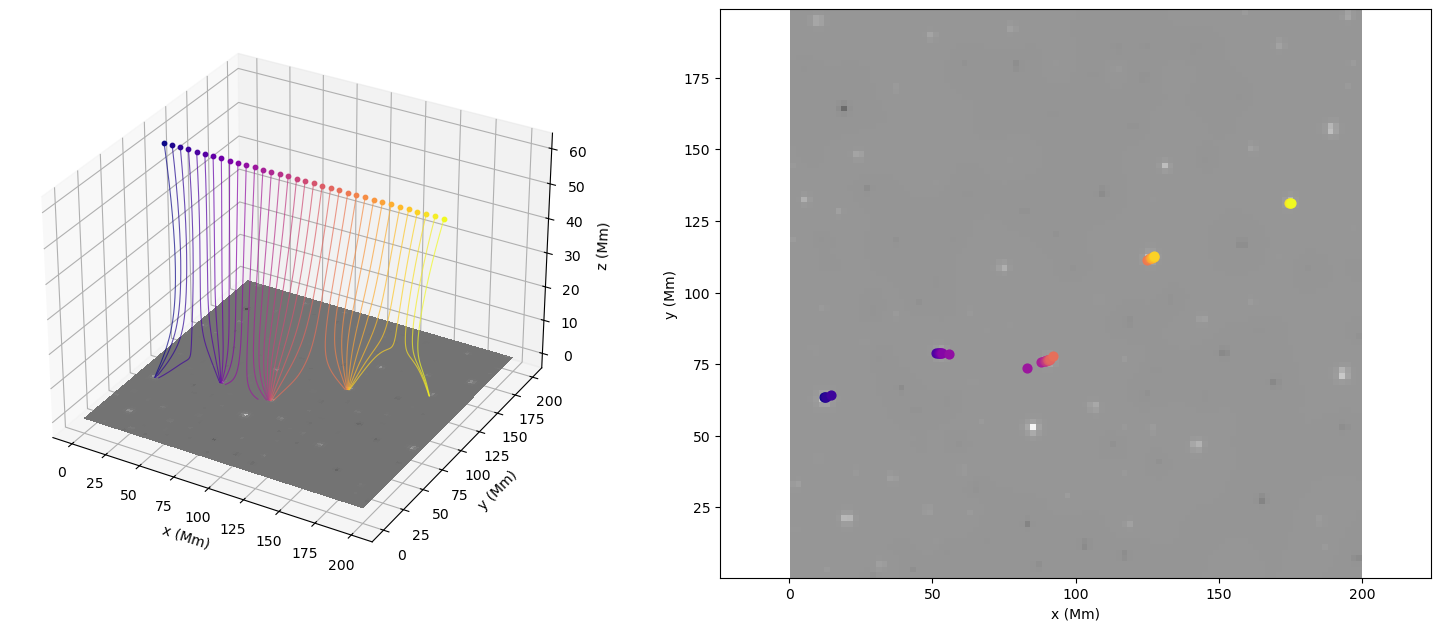

In [10]:
################# run #################
Z_PSP = 60 # 6000 # psp height in Mm
PSP_SPEED = 0.2 # Mm /s 
# ds = 0.05 # 0.05 # Mm
subsample = 30

t, x_psp, y_psp, z_psp_arr = make_psp_trajectory(z_psp=Z_PSP, speed=PSP_SPEED, y_offset=0, dt=1.0)

dt_sample = t[subsample] - t[0]  # time between each traced point
print(f'Time between sampled points: {dt_sample:.2f} s')

plot_fieldline_traces(x_psp, y_psp, z_psp_arr, t,
                      xi, yi, phi,       # step size in Mm
                      subsample=subsample) # every Nth PSP point

In [11]:
######## lets do this for a variety of positions
y_offsets = []
x_foots = []
y_foots = []
B_foots = []
B_psps = []

step = 50
for YOFFSET in tqdm(range(-150, 150+step, step)):
    # print(f'Tracing y_offset = {YOFFSET} Mm...')
    t, x_psp, y_psp, z_psp_arr = make_psp_trajectory(z_psp=Z_PSP, speed=PSP_SPEED, y_offset=YOFFSET, dt=1.0)
    x_foot, y_foot, B_foot, B_psp, idx = trace_all_footpoints(x_psp, y_psp, z_psp_arr, xi, yi, phi, subsample=subsample)

    y_offsets.append(YOFFSET)
    x_foots.append(x_foot)
    y_foots.append(y_foot)
    B_foots.append(B_foot)
    B_psps.append(B_psp)

# convert to arrays -- each row is one PSP pass
y_offsets = np.array(y_offsets)
x_foots   = np.array(x_foots)   # (n_passes, n_footpoints)
y_foots   = np.array(y_foots)
B_foots   = np.array(B_foots)
B_psps    = np.array(B_psps)

100%|██████████████████████████████████████████████████████████| 7/7 [00:11<00:00,  1.59s/it]


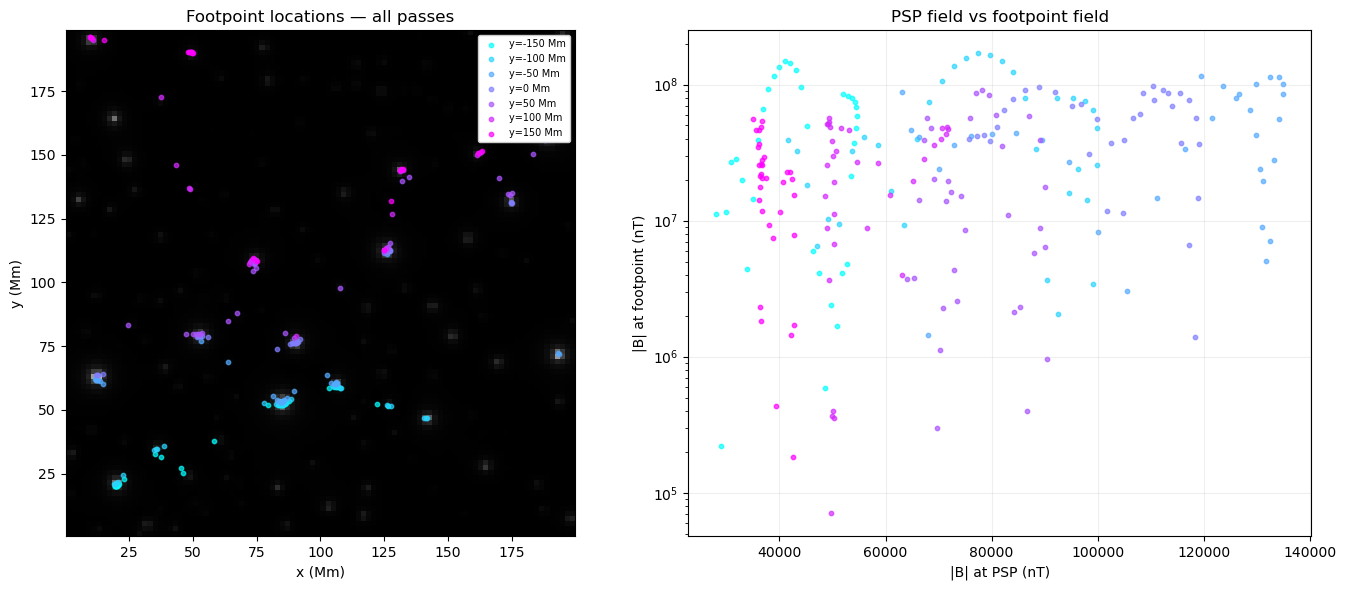

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# fig.patch.set_facecolor('#0d0d0d')

# background |B| at photosphere
X, Y = make_grid()
Bx_fl, By_fl, Bz_fl = calc_B(X, Y, 0.1, xi, yi, phi)
Bmag_floor = np.sqrt(Bx_fl**2 + By_fl**2 + Bz_fl**2)
extent = [X[0,0], X[0,-1], Y[0,0], Y[-1,0]]

colors_passes = plt.cm.cool(np.linspace(0, 1, len(y_offsets)))

# for ax in axes:
vmax = np.max(np.abs(Bmag_floor))
norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
axes[0].imshow(norm(Bmag_floor), origin='lower', extent=extent,
          cmap='Greys_r', aspect='equal')
    # ax.tick_params(colors='white')
    # for spine in ax.spines.values():
    #     spine.set_edgecolor('white')

# left: footpoint locations colored by pass
for color, x_foot, y_foot, YOFFSET in zip(colors_passes, x_foots, y_foots, y_offsets):
    axes[0].scatter(x_foot, y_foot, color=color, s=10, alpha=0.7,
                    label=f'y={YOFFSET} Mm')
axes[0].set_xlabel('x (Mm)')
axes[0].set_ylabel('y (Mm)')
axes[0].set_title('Footpoint locations — all passes')
axes[0].legend(fontsize=7, framealpha=1.0,
               loc='upper right')

# right: |B| at PSP vs |B| at footpoint, all passes
for color, B_foot, B_psp in zip(colors_passes, B_foots, B_psps):
    axes[1].scatter(B_psp, B_foot, color=color, s=10, alpha=0.7)
axes[1].set_xlabel('|B| at PSP (nT)')
axes[1].set_ylabel('|B| at footpoint (nT)')
axes[1].set_title('PSP field vs footpoint field')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---

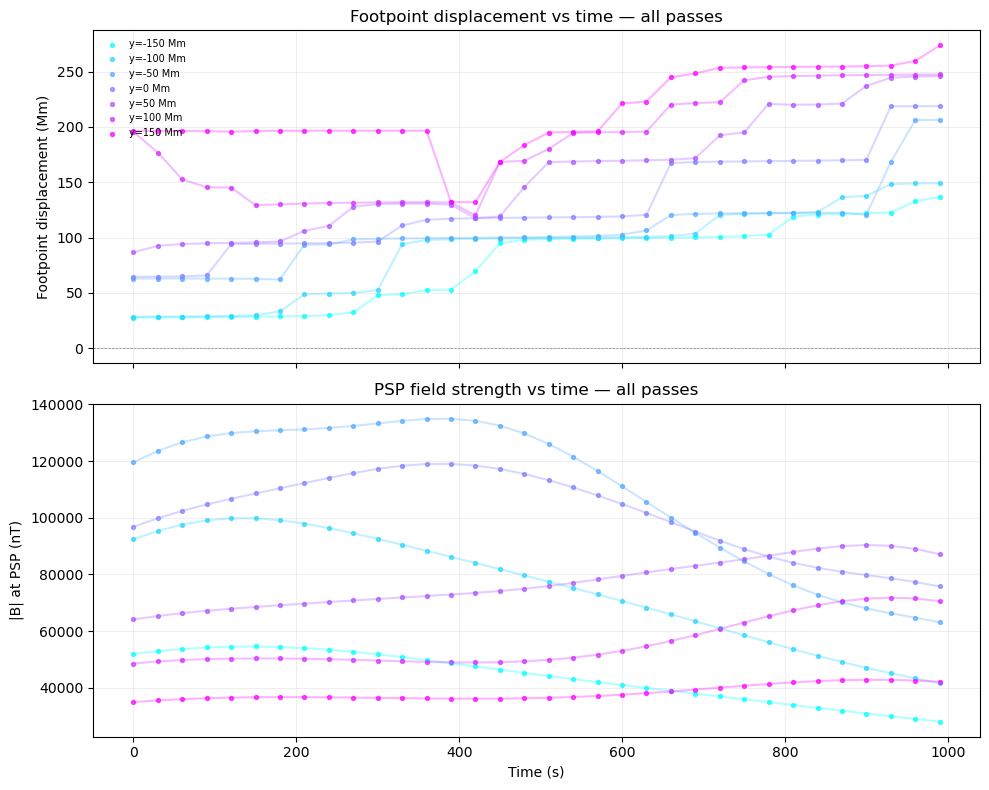

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# fig.patch.set_facecolor('#0d0d0d')

colors_passes = plt.cm.cool(np.linspace(0, 1, len(y_offsets)))

for ax in axes:
    # ax.set_facecolor('#0d0d0d')
    # ax.tick_params(colors='white')
    ax.grid(True, alpha=0.2)
    # for spine in ax.spines.values():
    #     spine.set_edgecolor('white')

# top: footpoint displacement over time, one line per pass
for color, x_foot, y_foot, YOFFSET in zip(colors_passes, x_foots, y_foots, y_offsets):
    t_foot = np.arange(len(x_foot))
    displacement = np.sqrt(x_foot**2 + y_foot**2)
    axes[0].scatter((t_foot * dt_sample), displacement,
                    color=color, s=8, alpha=0.7, label=f'y={YOFFSET} Mm')
    axes[0].plot((t_foot * dt_sample), displacement,
                    color=color, alpha=0.3)

axes[0].set_ylabel('Footpoint displacement (Mm)')
# axes[0].set_xlabel('Time (s)')
axes[0].set_title('Footpoint displacement vs time — all passes')
axes[0].legend(fontsize=7, framealpha=0, loc='upper left')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')

# bottom: |B| at PSP over time, one line per pass
for color, B_psp, YOFFSET in zip(colors_passes, B_psps, y_offsets):
    t_foot = np.arange(len(B_psp))
    axes[1].scatter(t_foot * dt_sample, B_psp,
                    color=color, s=8, alpha=0.7, label=f'y={YOFFSET} Mm')
    axes[1].plot(t_foot * dt_sample, B_psp, color=color, alpha=0.3)

axes[1].set_ylabel('|B| at PSP (nT)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('PSP field strength vs time — all passes')
# axes[1].legend(fontsize=7, framealpha=0, loc='upper right')

plt.tight_layout()
plt.show()

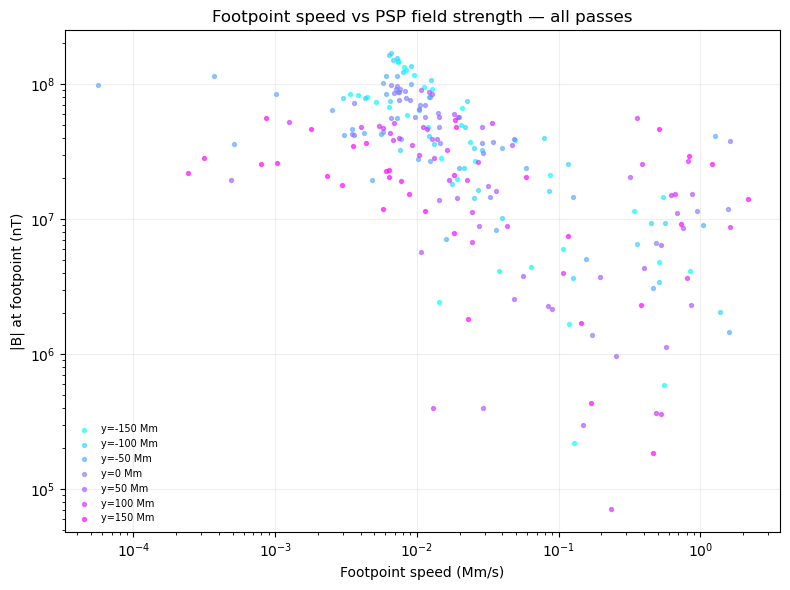

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
# fig.patch.set_facecolor('#0d0d0d')
# ax.set_facecolor('#0d0d0d')
# ax.tick_params(colors='white')
ax.grid(True, alpha=0.2)
# for spine in ax.spines.values():
#     spine.set_edgecolor('white')

for color, x_foot, y_foot, B_foot, YOFFSET in zip(colors_passes, x_foots, y_foots, B_foots, y_offsets):
    displacement = np.sqrt(x_foot**2 + y_foot**2)
    foot_speed   = np.abs(np.diff(displacement)) / dt_sample
    ax.scatter(foot_speed, B_foot[:-1],
               color=color, s=8, alpha=0.6, label=f'y={YOFFSET} Mm')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylabel('|B| at footpoint (nT)')
ax.set_xlabel('Footpoint speed (Mm/s)')
ax.set_title('Footpoint speed vs PSP field strength — all passes')
ax.legend(fontsize=7, framealpha=0)

plt.tight_layout()
plt.show()

---

In [15]:
filenames = ['data/full_xi0.00.out', 'data/full_xi0.10.out', 'data/full_xi0.20.out', 'data/full_xi0.30.out',
             'data/full_xi0.40.out', 'data/full_xi0.50.out', 'data/full_xi0.60.out', 'data/full_xi0.70.out',
             'data/full_xi0.80.out', 'data/full_xi0.90.out', 'data/full_xi0.99.out']

colors_files = plt.cm.plasma(np.linspace(0, 1, len(filenames)))

Z_SOURCES = -1.0   # Mm below photosphere
GAUSS = 10.0 * 1e5  # 1e17 Mx/Mm² → nanoTesla
Z_PSP = 60
PSP_SPEED = 0.2
YOFFSET = 0
subsample = 1 # one point every 0.2 Mm

x_foots = []
y_foots = []
B_foots = []
B_psps = []

for filename in tqdm(filenames):
    df = pd.read_csv(filename, sep=r'\s+', skiprows=2,
                     names=['Phi_i', 'x_i', 'y_i'], engine='python')
    
    xi = df.x_i.values
    yi = df.y_i.values
    phi = df.Phi_i.values

    t, x_psp, y_psp, z_psp_arr = make_psp_trajectory(z_psp=Z_PSP, speed=PSP_SPEED, y_offset=YOFFSET, dt=1.0)
    x_foot, y_foot, B_foot, B_psp, idx = trace_all_footpoints(x_psp, y_psp, z_psp_arr, xi, yi, phi, subsample=subsample)

    # y_offsets.append(YOFFSET)
    x_foots.append(x_foot)
    y_foots.append(y_foot)
    B_foots.append(B_foot)
    B_psps.append(B_psp)
    
# convert to arrays -- each row is one PSP pass
# y_offsets = np.array(y_offsets)
# x_foots   = np.array(x_foots)   # (n_passes, n_footpoints)
# y_foots   = np.array(y_foots)
# B_foots   = np.array(B_foots)
# B_psps    = np.array(B_psps)

dt_sample = t[subsample] - t[0]  # time between each traced point
print(f'Time between sampled points: {dt_sample:.2f} s')

100%|████████████████████████████████████████████████████████| 11/11 [06:51<00:00, 37.45s/it]

Time between sampled points: 1.00 s


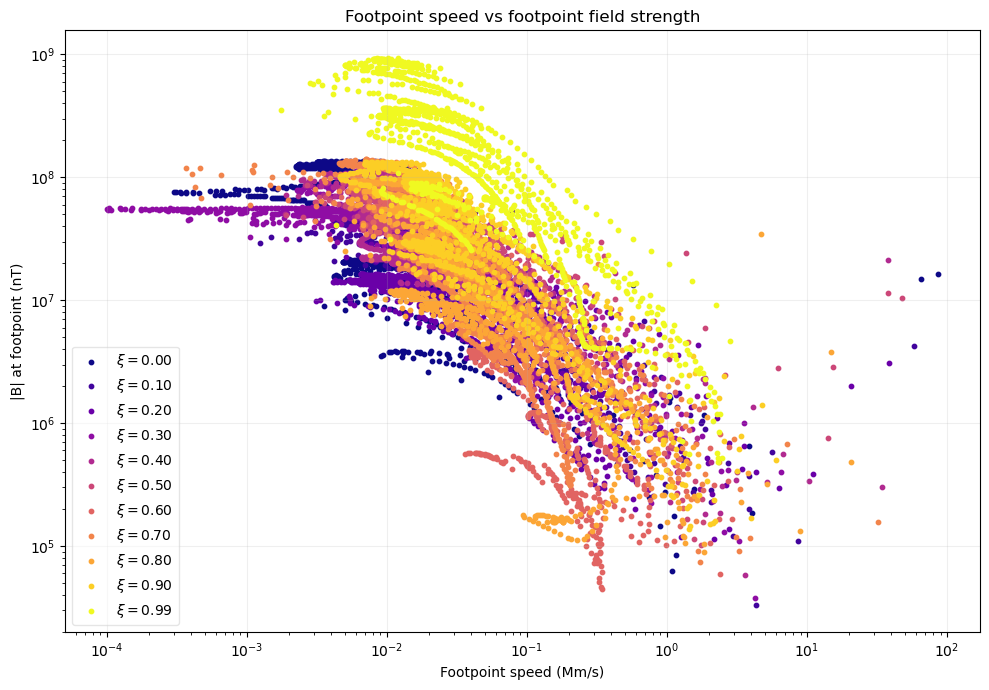

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.grid(True, alpha=0.2)

for color, x_foot, y_foot, B_foot, filename in zip(colors_files, x_foots, y_foots, B_foots, filenames):
    
    # displacement = np.sqrt(x_foot**2 + y_foot**2)
    # foot_speed   = np.abs(np.diff(displacement)) / dt_sample

    foot_speed = np.sqrt(np.diff(x_foot)**2 + np.diff(y_foot)**2) #/ dt_sample
    
    xi = filename.split('data/full_xi')[1].rstrip('.out')
    ax.scatter(foot_speed, B_foot[:-1],
               color=color, s=10, alpha=1.0, label=rf'$\xi = ${xi}')

ax.set_yscale('log')
ax.set_xscale('log')

ax.set_ylabel('|B| at footpoint (nT)')
ax.set_xlabel('Footpoint speed (Mm/s)')
ax.set_title('Footpoint speed vs footpoint field strength')
ax.legend(fontsize=10, framealpha=0.5)

plt.tight_layout()
plt.show()

In [179]:
def bkn_pow_smooth(x, A, x_b, a_1, a_2, delta):
    a_1 *= -1
    a_2 *= -1
    return A*(x/x_b)**(-a_1) * (0.5*(1+(x/x_b)**(1/delta)))**((a_1-a_2)*delta)

def bkn_pow_smooth_log(log_x, A, x_b, a_1, a_2, delta):
    x = 10**log_x
    return np.log10(bkn_pow_smooth(x, A, x_b, a_1, a_2, delta))

# def bkn_pow_smooth(x, A, x_b, a, delta_a, delta):
#     a1 = a + 0.5 * delta_a
#     a2 = a - 0.5 * delta_a
    
#     a1 *= -1
#     a2 *= -1
    
#     return A*(x/x_b)**(-a1) * (0.5*(1+(x/x_b)**(1/delta)))**((a1-a2)*delta)

def fitting_func(xdata, ydata, errorbar=True):

    # bin in log space and compute mean + std per bin
    n_bins = 20
    bins = np.logspace(np.log10(xdata.min()), np.log10(xdata.max()), n_bins + 1)
    bin_centers = np.sqrt(bins[:-1] * bins[1:])  # geometric mean of bin edges
    
    bin_mean = np.zeros(n_bins)
    bin_std  = np.zeros(n_bins)
    bin_mask = np.zeros(n_bins, dtype=bool)
    
    for j in range(n_bins):
        in_bin = (xdata >= bins[j]) & (xdata < bins[j+1])
        if in_bin.sum() > 3: # bin must have more than 3 points
            bin_mean[j] = np.mean(ydata[in_bin])
            bin_std[j]  = np.std(ydata[in_bin])
            bin_mask[j] = True

    if errorbar == True:
        ax.errorbar(bin_centers[bin_mask], bin_mean[bin_mask], yerr=bin_std[bin_mask],
                    fmt='o', color=color, ecolor=color, elinewidth=1.5,
                    capsize=3, ms=5, zorder=5, label='binned mean ± std')
    
    # fit
    # popt, pcov = curve_fit(bkn_pow_smooth, xdata, ydata, p0=[10**8, 1e-4, 1e-3, 1e-1, 1])
    popt, pcov = curve_fit(
        bkn_pow_smooth_log,
        np.log10(bin_centers[bin_mask]),
        np.log10(bin_mean[bin_mask]),
        p0=[10**8, 2e-4, 1e-3, 1e-1, 0.5],
        # p0=[1e+07, 1e-03, 1e-1, +1, -1e-03],
        sigma = np.log10(bin_std[bin_mask]), # error estimate
        bounds = ([1e6, 1e-4, -1, -1, 0.01],   # lower bounds
                  [1e9, 1e-1,  1,  1, 1]       # upper bounds
                 )
    )

    return popt, pcov, bin_centers, bin_mask, bin_std

[ 5.77290501e+07  1.08785938e-02  4.57560503e-02 -9.13099814e-01
  1.34964490e-01]
112515915.33645557


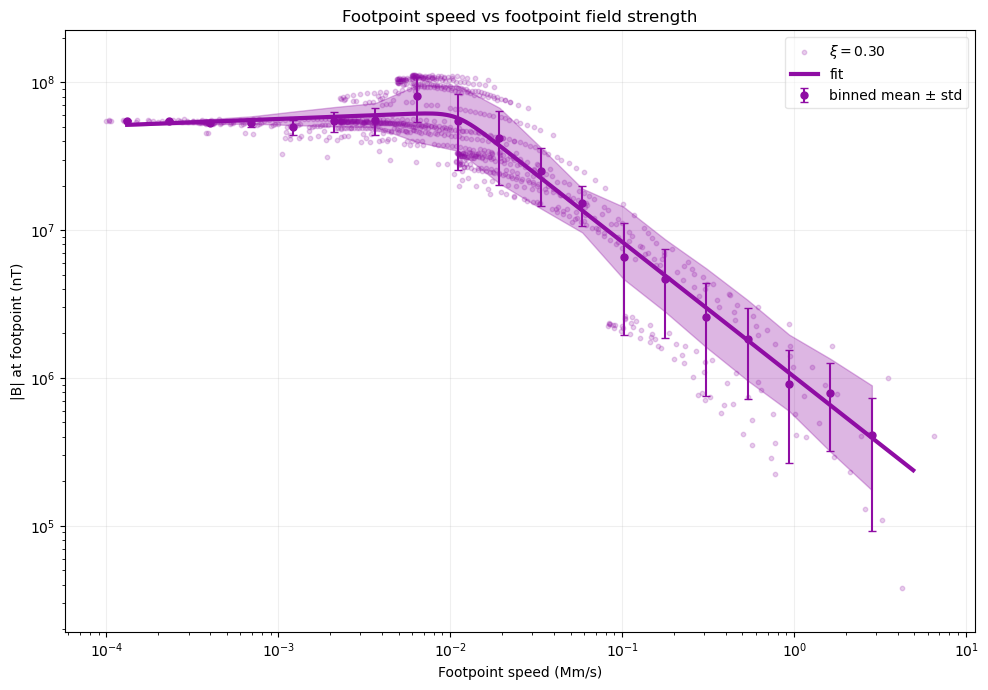

In [180]:
i = 3

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, alpha=0.2)
color, x_foot, y_foot, B_foot, filename = colors_files[i], x_foots[i], y_foots[i], B_foots[i], filenames[i]

# displacement = np.sqrt(x_foot**2 + y_foot**2)
# foot_speed   = np.abs(np.diff(displacement)) / dt_sample

foot_speed = np.sqrt(np.diff(x_foot)**2 + np.diff(y_foot)**2)

xi = filename.split('data/full_xi')[1].rstrip('.out')

xdata = foot_speed
ydata = B_foot[:-1]

ax.scatter(xdata, ydata, color=color, s=10, alpha=0.2, label=rf'$\xi = ${xi}') # scatterplot

popt, pcov, bin_centers, bin_mask, bin_std = fitting_func(xdata, ydata) # fitting

print(popt)

x = np.logspace(np.log10(bin_centers[0]), np.log10(bin_centers[-1]), 500)
ax.plot(x, bkn_pow_smooth(x, *popt), c=color, zorder=10, linewidth=3, label='fit')


sigma = bin_std[bin_mask]
y = bkn_pow_smooth(bin_centers[bin_mask], *popt)
sigma_log = sigma / (y * np.log(10))

y_upper = y * 10**(sigma_log)
y_lower = y * 10**(-sigma_log)

ax.fill_between(bin_centers[bin_mask],
                y_upper,
                y_lower,
                color=color, alpha=0.3, zorder=4)


# shade 1 std
# ax.fill_between(bin_centers[bin_mask],
#                 bkn_pow_smooth(bin_centers[bin_mask], *popt) + bin_std[bin_mask],
#                 bkn_pow_smooth(bin_centers[bin_mask], *popt) - bin_std[bin_mask],
#                 color=color, alpha=0.3, zorder=4)

ax.set_ylabel('|B| at footpoint (nT)')
ax.set_xlabel('Footpoint speed (Mm/s)')
ax.set_title('Footpoint speed vs footpoint field strength')
ax.set_ylim(np.nanmin(B_foot)/2, np.nanmax(B_foot)*2)
print(np.nanmax(B_foot)+10000)
ax.legend(fontsize=10, framealpha=0.5)
plt.tight_layout()
plt.show()

In [181]:
# def bkn_pow_smooth(x, A, x_b, a_1, a_2, delta):
#     a_1 *= -1
#     a_2 *= -1
#     return A*(x/x_b)**(-a_1) * (0.5*(1+(x/x_b)**(1/delta)))**((a_1-a_2)*delta)

# def bkn_pow_smooth_log(log_x, A, x_b, a_1, a_2, delta):
#     x = 10**log_x
#     return np.log10(bkn_pow_smooth(x, A, x_b, a_1, a_2, delta))

# i = 3

# fig, ax = plt.subplots(figsize=(10, 7))
# ax.grid(True, alpha=0.2)
# color, x_foot, y_foot, B_foot, filename = colors_files[i], x_foots[i], y_foots[i], B_foots[i], filenames[i]

# # displacement = np.sqrt(x_foot**2 + y_foot**2)
# # foot_speed   = np.abs(np.diff(displacement)) / dt_sample

# foot_speed = np.sqrt(np.diff(x_foot)**2 + np.diff(y_foot)**2)

# xi = filename.split('data/full_xi')[1].rstrip('.out')

# xdata = foot_speed
# ydata = B_foot[:-1]

# # scatter
# ax.scatter(xdata, ydata, color=color, s=10, alpha=0.2, label=rf'$\xi = ${xi}')

# # bin in log space and compute mean + std per bin
# n_bins = 20
# bins = np.logspace(np.log10(xdata.min()), np.log10(xdata.max()), n_bins + 1)
# bin_centers = np.sqrt(bins[:-1] * bins[1:])  # geometric mean of bin edges

# bin_mean = np.zeros(n_bins)
# bin_std  = np.zeros(n_bins)
# bin_mask = np.zeros(n_bins, dtype=bool)

# for j in range(n_bins):
#     in_bin = (xdata >= bins[j]) & (xdata < bins[j+1])
#     if in_bin.sum() > 3: # bin must have more than 3 points
#         bin_mean[j] = np.mean(ydata[in_bin])
#         bin_std[j]  = np.std(ydata[in_bin])
#         bin_mask[j] = True

# ax.errorbar(bin_centers[bin_mask], bin_mean[bin_mask], yerr=bin_std[bin_mask],
#             fmt='o', color=color, ecolor=color, elinewidth=1.5,
#             capsize=3, ms=5, zorder=5, label='binned mean ± std')

# # fit
# # popt, pcov = curve_fit(bkn_pow_smooth, xdata, ydata, p0=[10**8, 1e-4, 1e-3, 1e-1, 1])
# popt, pcov = curve_fit(
#     bkn_pow_smooth_log,
#     np.log10(bin_centers[bin_mask]),
#     np.log10(bin_mean[bin_mask]),
#     p0=[10**8, 1e-4, 1e-3, 1e-1, 1],
#     sigma = np.log10(bin_std[bin_mask]) # error estimate
# )
# print(popt)
# x = np.logspace(np.log10(bin_centers[0]), np.log10(bin_centers[-1]), 500)
# ax.plot(x, bkn_pow_smooth(x, *popt), c=color, zorder=10, linewidth=3, label='fit')


# # shade 1 std
# ax.fill_between(bin_centers[bin_mask],
#                 bkn_pow_smooth(bin_centers[bin_mask], *popt) + bin_std[bin_mask],
#                 bkn_pow_smooth(bin_centers[bin_mask], *popt) - bin_std[bin_mask],
#                 color=color, alpha=0.3, zorder=4)

# ax.set_yscale('log')
# ax.set_xscale('log')
# ax.set_ylabel('|B| at footpoint (nT)')
# ax.set_xlabel('Footpoint speed (Mm/s)')
# ax.set_title('Footpoint speed vs footpoint field strength')
# ax.legend(fontsize=10, framealpha=0.5)
# plt.tight_layout()
# plt.show()

/var/folders/gl/_0dnbww96fj8wsb5gb4qzm2r0000gn/T/ipykernel_95136/389568679.py:4: RuntimeWarning: overflow encountered in power
  return A*(x/x_b)**(-a_1) * (0.5*(1+(x/x_b)**(1/delta)))**((a_1-a_2)*delta)


fit failed :(


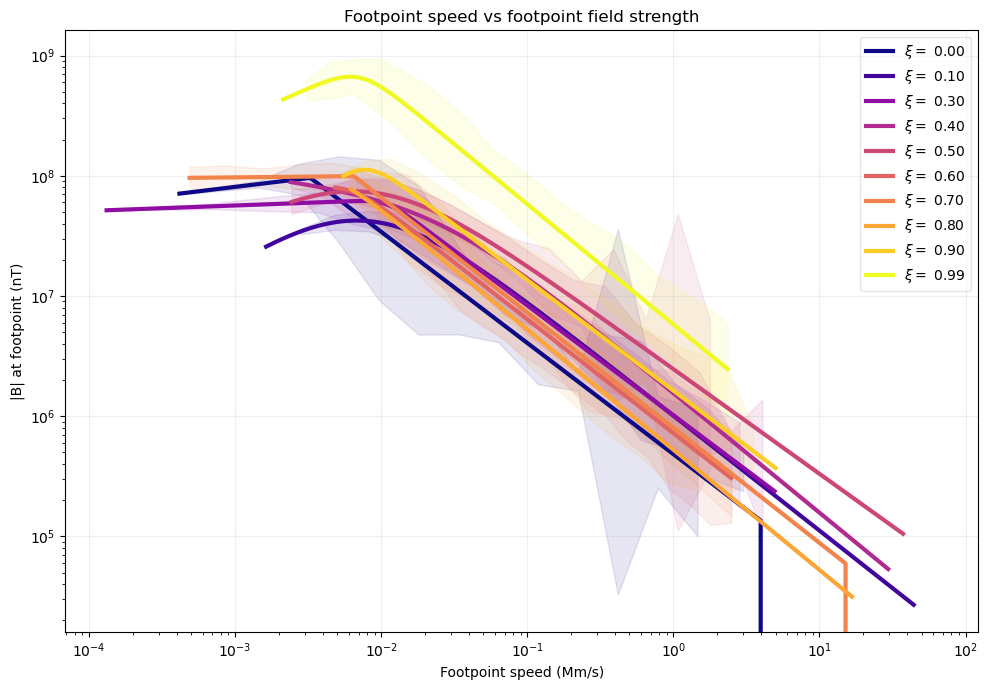

In [182]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.grid(True, alpha=0.2)

xis = []
popts = []
pcovs = []

# for i in range(0, 6):
for i in range(len(filenames)):

    color, x_foot, y_foot, B_foot, filename = colors_files[i], x_foots[i], y_foots[i], B_foots[i], filenames[i]
    
    foot_speed = np.sqrt(np.diff(x_foot)**2 + np.diff(y_foot)**2)
    
    xi = filename.split('data/full_xi')[1].rstrip('.out')
    
    xdata = foot_speed
    ydata = B_foot[:-1]

    try:
        popt, pcov, bin_centers, bin_mask, bin_std = fitting_func(xdata, ydata, errorbar=False) # fitting
        x = np.logspace(np.log10(bin_centers[0]), np.log10(bin_centers[-1]), 500)
        ax.plot(x, bkn_pow_smooth(x, *popt), c=color, zorder=10, linewidth=3, label=rf'$\xi =$ {xi}')

        sigma = bin_std[bin_mask]
        y = bkn_pow_smooth(bin_centers[bin_mask], *popt)
        sigma_log = sigma / (y * np.log(10))

        y_upper = y * 10**(sigma_log)
        y_lower = y * 10**(-sigma_log)

        ax.fill_between(bin_centers[bin_mask],
                        y_upper,
                        y_lower,
                        color=color, alpha=0.1, zorder=0)

        # shade 1 std
        # ax.fill_between(bin_centers[bin_mask],
        #                 bkn_pow_smooth(bin_centers[bin_mask], *popt) + bin_std[bin_mask],
        #                 bkn_pow_smooth(bin_centers[bin_mask], *popt) - bin_std[bin_mask],
        #                 color=color, alpha=0.1, zorder=0)

    except:
        print('fit failed :(')
        popt, pcov = np.nan, np.nan
        

    # # bin in log space and compute mean + std per bin
    # n_bins = 20
    # bins = np.logspace(np.log10(xdata.min()), np.log10(xdata.max()), n_bins + 1)
    # bin_centers = np.sqrt(bins[:-1] * bins[1:])  # geometric mean of bin edges
    
    # bin_mean = np.zeros(n_bins)
    # bin_std  = np.zeros(n_bins)
    # bin_mask = np.zeros(n_bins, dtype=bool)
    
    # for j in range(n_bins):
    #     in_bin = (xdata >= bins[j]) & (xdata < bins[j+1])
    #     if in_bin.sum() > 3: # bin must have more than 3 points
    #         bin_mean[j] = np.mean(ydata[in_bin])
    #         bin_std[j]  = np.std(ydata[in_bin])
    #         bin_mask[j] = True

    # try:
    #     popt, pcov = curve_fit(
    #         bkn_pow_smooth_log,
    #         np.log10(bin_centers[bin_mask]),
    #         np.log10(bin_mean[bin_mask]),
    #         p0=[10**8, 1e-4, 1e-3, 1e-1, 1],
    #         sigma = np.log10(bin_std[bin_mask]) # error estimated by std
    #     )
    #     # print(popt)
    #     x = np.logspace(np.log10(bin_centers[0]), np.log10(bin_centers[-1]), 500)
    #     ax.plot(x, bkn_pow_smooth(x, *popt), c=color, zorder=10, linewidth=3, label=rf'$\xi =$ {xi}')
    
    
    #     # shade 1 std
    #     ax.fill_between(bin_centers[bin_mask],
    #                     bkn_pow_smooth(bin_centers[bin_mask], *popt) + bin_std[bin_mask],
    #                     bkn_pow_smooth(bin_centers[bin_mask], *popt) - bin_std[bin_mask],
    #                     color=color, alpha=0.1, zorder=0)

    # except:
    #     print('fit failed :(')
    #     popt, pcov = np.nan, np.nan


    xis.append(xi)
    popts.append(popt); pcovs.append(pcov)



# # ---- fit to all data combined ----
# # all_x_foot = np.concatenate(x_foots)
# # all_y_foot = np.concatenate(y_foots)
# all_v = np.sqrt(np.diff(x_foots)**2 + np.diff(y_foots)**2) 
# all_xdata = np.concatenate(all_v)

# new_B_foots = []
# for B in B_foots:
#     new_B_foots.append(B[:-1])
# all_ydata = np.concatenate(new_B_foots)

# n_bins = 20
# bins = np.logspace(np.log10(all_xdata.min()), np.log10(all_xdata.max()), n_bins + 1)
# bin_centers = np.sqrt(bins[:-1] * bins[1:])
# bin_mean = np.zeros(n_bins)
# bin_std  = np.zeros(n_bins)
# bin_mask = np.zeros(n_bins, dtype=bool)

# for j in range(n_bins):
#     in_bin = (all_xdata >= bins[j]) & (all_xdata < bins[j+1])
#     if in_bin.sum() > 3:
#         bin_mean[j] = np.mean(all_ydata[in_bin])
#         bin_std[j]  = np.std(all_ydata[in_bin])
#         bin_mask[j] = True

# try:
#     popt_all, pcov_all = curve_fit(
#         bkn_pow_smooth_log,
#         np.log10(bin_centers[bin_mask]),
#         np.log10(bin_mean[bin_mask]),
#         p0=[10**8, 1e-4, 1e-3, 1e-1, 1],
#         sigma=np.log10(bin_std[bin_mask])
#     )
#     x = np.logspace(np.log10(bin_centers[0]), np.log10(bin_centers[-1]), 500)
#     ax.plot(x, bkn_pow_smooth(x, *popt_all),
#             c='white', zorder=20, linewidth=3, ls='--', label='combined fit')
#     ax.fill_between(bin_centers[bin_mask],
#                     bkn_pow_smooth(bin_centers[bin_mask], *popt_all) + bin_std[bin_mask],
#                     bkn_pow_smooth(bin_centers[bin_mask], *popt_all) - bin_std[bin_mask],
#                     color='white', alpha=0.1, zorder=0)
#     print(f'Combined fit: A={popt_all[0]:.3e}, x_b={popt_all[1]:.3e}, '
#           f'a1={popt_all[2]:.3f}, da={popt_all[3]:.3f}, delta={popt_all[4]:.3f}')
# except:
#     print('combined fit failed :(')



ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('|B| at footpoint (nT)')
ax.set_xlabel('Footpoint speed (Mm/s)')
ax.set_title('Footpoint speed vs footpoint field strength')
ax.legend(fontsize=10, framealpha=0.5)
plt.tight_layout()
plt.show()

In [183]:
A = []
xb = []
a1 = []
a2 = []
delta = []

A_err = []
xb_err = []
a1_err = []
a2_err = []
delta_err = []

for popt, pcov in zip(popts, pcovs):
    try:
        A.append(popt[0])
        xb.append(popt[1])
        a1.append(popt[2])
        a2.append(popt[3])
        delta.append(popt[4])

        perr = np.sqrt(np.diag(pcov))

        A_err.append(perr[0])
        xb_err.append(perr[1])
        a1_err.append(perr[2])
        a2_err.append(perr[3])
        delta_err.append(perr[4])

    except: # fit didnt work so filled w nans
        A.append(np.nan)
        xb.append(np.nan)
        a1.append(np.nan)
        a2.append(np.nan)
        delta.append(np.nan)

        A_err.append(np.nan)
        xb_err.append(np.nan)
        a1_err.append(np.nan)
        a2_err.append(np.nan)
        delta_err.append(np.nan)

In [184]:
params = {'A':A, 'x_b':xb, 'a_1':a1, 'a_2':a2, 'delta':delta} # Must match func arguments order

# 3. Create a DataFrame
df_results = pd.DataFrame(params, index=xis)

df_results

,A,x_b,a_1,a_2,delta
0.00,9.541801e+07,0.003268,0.146998,-0.924980,0.010009
0.10,4.221561e+07,0.007615,0.821020,-0.956989,0.759343
0.20,NaN,NaN,NaN,NaN,NaN
0.30,5.772905e+07,0.010879,0.045756,-0.913100,0.134964
0.40,4.063497e+07,0.023650,-0.149177,-0.997512,0.812869
0.50,7.324039e+07,0.008038,0.653594,-0.872090,0.771391
0.60,7.886379e+07,0.005176,0.532793,-0.946695,0.283604
0.70,9.855088e+07,0.006507,0.012772,-0.957683,0.010925
0.80,9.326992e+07,0.004847,-0.370544,-0.999952,0.343812
0.90,1.121544e+08,0.007562,1.000000,-0.920553,0.199454


xb mean: 0.00845
a1 mean: 0.32431
a2 mean: -0.94896
delta mean: 0.35438


Text(0, 0.5, '$\\delta$')

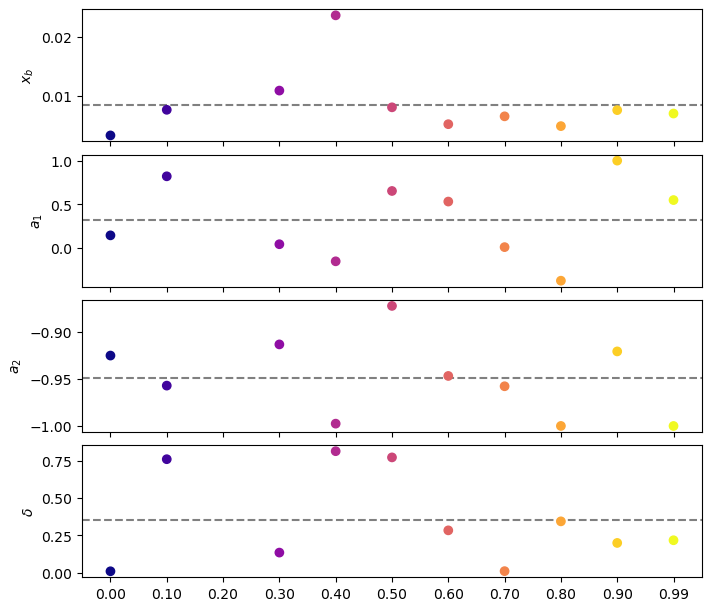

In [185]:
fig, ax = plt.subplots(4, 1, layout='compressed', sharex=True, figsize=(7, 6))

ax[0].scatter(xis, xb, color=colors_files)
# ax[0].errorbar(xis, xb, yerr=xb_err, fmt='none', color='k', zorder=0)
ax[0].axhline(np.nanmean(xb), color='grey', linestyle='--', zorder=0)
print(f'xb mean: {np.nanmean(xb):.5f}')
ax[0].set_ylabel(r'$x_b$')

ax[1].scatter(xis, a1, color=colors_files)
# ax[1].errorbar(xis, a1, yerr=a1_err, fmt='none', color='k', zorder=0)
ax[1].axhline(np.nanmean(a1), color='grey', linestyle='--', zorder=0)
print(f'a1 mean: {np.nanmean(a1):.5f}')
ax[1].set_ylabel(r'$a_1$')

ax[2].scatter(xis, a2, color=colors_files)
# ax[2].errorbar(xis, a2, yerr=a2_err, fmt='none', color='k', zorder=0)
ax[2].axhline(np.nanmean(a2), color='grey', linestyle='--', zorder=0)
print(f'a2 mean: {np.nanmean(a2):.5f}')
ax[2].set_ylabel(r'$a_2$')

ax[3].scatter(xis, delta, color=colors_files)
# ax[3].errorbar(xis, delta, yerr=delta_err, fmt='none', color='k', zorder=0)
ax[3].axhline(np.nanmean(delta), color='grey', linestyle='--', zorder=0)
print(f'delta mean: {np.nanmean(delta):.5f}')
ax[3].set_ylabel(r'$\delta$')

# ax[0].set_yscale('log')
# ax[1].set_yscale('log')
# ax[2].set_yscale('log')
# ax[3].set_yscale('log')